We begin by importing the libraries we will use:

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from scipy import stats

from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import KNNImputer, IterativeImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.diagnostic import het_breuschpagan, het_white
from statsmodels.stats.outliers_influence import variance_inflation_factor, OLSInfluence
from statsmodels.stats.multicomp import pairwise_tukeyhsd

sns.set_theme(style="whitegrid", context="talk")
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 100)

# 1. Describe the Dataset
We begin by loading and describing the dataset. First, we read the csv
file into a dataframe. We then use $\texttt{head()}$ to get a peak at the 
data and what types of data are there.

We then want to describe the dataset. We follow the scheme set out in the example notebook. We want to describe the type of data (continuous vs discrete; if discrete, is it nominal, ordinal, or categorical). $\texttt{Pandas}$'s $\texttt{dtypes}$ and $\texttt{info()}$ methods can help with this. We then want to describe what it is, which is provided int the homework assignment document. To obtain the typical range and why it matters, we can look online to find out about PSA. 

In [2]:
prostate_raw_csv = pd.read_csv('prostate.csv')
prostate_raw_csv.head(10)

,lcavol,lweight,age,lbph,svi,lcp,gleason,pgg45,lpsa,train
0,-0.579818,2.769459,50,-1.386294,0,-1.386294,6,0,-0.430783,True
1,-0.994252,3.319626,58,-1.386294,0,-1.386294,6,0,-0.162519,True
2,-0.510826,2.691243,74,-1.386294,0,-1.386294,7,20,-0.162519,True
3,-1.203973,3.282789,58,-1.386294,0,-1.386294,6,0,-0.162519,True
4,0.751416,3.432373,62,-1.386294,0,-1.386294,6,0,0.371564,True
5,-1.049822,3.228826,50,-1.386294,0,-1.386294,6,0,0.765468,True
6,0.737164,3.473518,64,0.615186,0,-1.386294,6,0,0.765468,False
7,0.693147,3.539509,58,1.536867,0,-1.386294,6,0,0.854415,True
8,-0.776529,3.539509,47,-1.386294,0,-1.386294,6,0,1.047319,False
9,0.223144,3.244544,63,-1.386294,0,-1.386294,6,0,1.047319,False


In [3]:
print('Info')
display(prostate_raw_csv.info())
print('\n Dtypes: \n')
print(prostate_raw_csv.dtypes)
print('\n Describe: \n')
display(prostate_raw_csv.describe(include="all").T)
print("\nrows, columns: ", prostate_raw_csv.shape)

Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 97 entries, 0 to 96
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   lcavol   97 non-null     float64
 1   lweight  97 non-null     float64
 2   age      97 non-null     int64  
 3   lbph     97 non-null     float64
 4   svi      97 non-null     int64  
 5   lcp      97 non-null     float64
 6   gleason  97 non-null     int64  
 7   pgg45    97 non-null     int64  
 8   lpsa     97 non-null     float64
 9   train    97 non-null     bool   
dtypes: bool(1), float64(5), int64(4)
memory usage: 7.0 KB


None


 Dtypes: 

lcavol     float64
lweight    float64
age          int64
lbph       float64
svi          int64
lcp        float64
gleason      int64
pgg45        int64
lpsa       float64
train         bool
dtype: object

 Describe: 



,count,unique,top,freq,mean,std,min,25%,50%,75%,max
lcavol,97.0,NaN,NaN,NaN,1.35001,1.178625,-1.347074,0.512824,1.446919,2.127041,3.821004
lweight,97.0,NaN,NaN,NaN,3.628943,0.428411,2.374906,3.37588,3.623007,3.876396,4.780383
age,97.0,NaN,NaN,NaN,63.865979,7.445117,41.0,60.0,65.0,68.0,79.0
lbph,97.0,NaN,NaN,NaN,0.100356,1.450807,-1.386294,-1.386294,0.300105,1.558145,2.326302
svi,97.0,NaN,NaN,NaN,0.216495,0.413995,0.0,0.0,0.0,0.0,1.0
lcp,97.0,NaN,NaN,NaN,-0.179366,1.39825,-1.386294,-1.386294,-0.798508,1.178655,2.904165
gleason,97.0,NaN,NaN,NaN,6.752577,0.722134,6.0,6.0,7.0,7.0,9.0
pgg45,97.0,NaN,NaN,NaN,24.381443,28.204035,0.0,0.0,15.0,40.0,100.0
lpsa,97.0,NaN,NaN,NaN,2.478387,1.154329,-0.430783,1.731656,2.591516,3.056357,5.582932
train,97,2,True,67,NaN,NaN,NaN,NaN,NaN,NaN,NaN



rows, columns:  (97, 10)


## The Variables

#### 1. $\texttt{lcavol}$ (Continuous, Numeric)
**Explanatory Variable**

**What it is:** the logarithm of the cancer volume.

**Typical Range:** According to a study by Antunes et. al., the typical range of tumor volume in patients undergoing radical prostatectomy is 0.4 to 20 cm $^{3}$ [1]. This corresponds to a log cancer volume of -0.916 to 3.00.

**Why it matters:** Tumor volume is one of the most important factors associated with prostate cancer. It is an indicator of the severity of cancer and likelihood of recurrence [1].

**Practical Note:** These values are logarithm, so the numeric values don't correspond to a real unit of measurement. Cancer volume is always positive, but log cancer value is sometimes negative. We plot log cancer volume instead of cancer volume directly because the raw cancer volume data is right-skewed and thus too blatantly violates linearity assumptions. Taking the logarithm decreases the absolute value of the skewness from 2.183 to 0.250 (see graph above), so the linearity assumption is more accurate.

#### 2. $\texttt{lweight}$ (Continuous, Numeric)
**Explanatory Variable**

**What it is:** Logarithm of the prostate weight.

**Typical Range:** A normal prostate weighs 15-30 grams [2]. However, prostate cancer can cause enlargement. One study found the median prostate weight of cancer patients to be 62.9 grams with a range of 10-260 [3]. Taking the logarithm, this corresponds to 2.7 to 3.4 for healthy men, and 2.3 to 5.6 for men with prostate cancer.

**Why it matters:** Prostate weight is known to increase with age even in healthy, cancer-free men [5]. Thus, while cancer can cause increase in prostate weight, this can also be a function of age. Studies have shown that PSA correlates with overall prostate weight for larger prostates and with tumor volume for small/medium prostates [6].

**Practical Note:** Again, we are working with logarithm, and therefore not real units, because the original data is right-skewed (skewness of 1.63).

#### 3. $\texttt{age}$ (Discrete, Nominal)
**Explanatory Variable**

**What it is:** Age of patient, in discrete terms (months not taken into account).

**Typical Range:** The typical range of men undergoing radical prostatectomy is 41-80 [8].

**Why it matters:** Age is known to be correlated with higher PSA levels, regardless of presence of prostate cancer [4]. This is important to be taken into account when considering PSA's correlation with prostate cancer. The incidence of prostate cancer is also known to increase with age (as is true with cancer in general) [7].

**Practical Note:** Age is treated as a discrete variable here although it is in fact continuous.

#### 4. $\texttt{lbph}$ (Continuous, Numeric)
**Explanatory Variable**

**What it is:** Logarithm of the amount of benign prostatic hyperplasia. BPH is prostate enlargement, and generally becomes more prevalent with increasing age [9].

**Typical Range:** Units of measurement unclear, so comparison with the literature is not possible in this case.

**Why it matters:** BPH is a noncancerous condition also associated with enlarged prostate and elevated PSA, but does not present risk of spreading to other parts of the body [10].

#### 5. $\texttt{svi}$ (Discrete, Binary)
**Explanatory Variable**

**What it is:** Presence of seminal vesicle invasion: invasion of the muscular wall of the seminal vessels by prostate cancer.

**Typical Range:** This is a binary marker, so the range is (0, 1).

**Why it matters:** Seminal vesicle invasion is a marker of the severity of the cancer, and indicates that cancer has a high likelihood of recurring even after radical prostatectomy [11].

**Practical Note:** This is saved as an $\texttt{int}$ not a $\texttt{bool}$, but it is in fact binary.

#### 6. $\texttt{lcp}$ (Continuous, Numeric)
**Explanatory Variable**

**What it is:** Logarithm of capsular penetration, indicating cancer spread outside the prostate.

**Typical Range:** 20-66% [12]. However, it is unclear what units were used for measurement in this study so this cannot be translated to typical range for our dataset.

**Why it matters:** Along with $\texttt{svi}$, capsular penetration is a marker of prostate cancer severity [12]. $\texttt{lcp}$ has the advantage of being a continuous indicator.

**Practical Note:** Very small values of capsular penetration cannot be measured, so in this case it is arbitrarily set to 0.25.

#### 7. $\texttt{gleason}$ (Discrete, Ordinal)
**Explanatory Variable**

**What it is:** Gleason score, a grading system for prostate cancer aggressiveness.

**Typical Range:** 6-10 [13].

**Why it matters:** It is a system for categorizing the aggressiveness of prostate cancer and the speed of cancer spread.

#### 8. $\texttt{pgg45}$ (Discrete, Numeric)
**Explanatory Variable**

**What it is:** Percentage of Gleason scores of 4 or 5 recorded in the patient's visit history before their final Gleason score.

**Why it matters:** Provides insight into the patient's past cancer severity.

**Practical Note:** Even though percentages are in theory continuous values, in this study, percentages are recorded as $\texttt{int64}$ (i.e., they are discrete).

#### 9. Target/Dependent Variable: $\texttt{lpsa}$ (Continuous, Numeric)
**Target/Dependent Variable**

**What it is:** Logarithm of the PSA score.

**Typical Range:** Healthy PSA levels vary widely by age. For men below 50, values higher than 2.5 ng/mL are considered abnormal, but even 5.5 is normal for men aged 70-80. Thus, PSA scores in healthy men range from 0 to 5.5 ng/mL [15]. Prostate levels can exceed 10 ng/mL in prostate cancer patients [16]. Taking the natural logarithm, PSA levels in the range of 1.39 to 20 ng/mL correspond to values of 1.39 to 3.00.

**Practical Note:** PSA scores vary widely by age and racial group.

Values of svi:  [0 1]
Values of gleason:  [6 7 8 9]
Values of pgg45:  [  0  20  30   5  60  70  80  15  35  10   6 100  40  50   4  95  25  90
  75]


Looking a little closer at the lcavol data
<class 'pandas.core.series.Series'>


count    97.000000
mean      7.000825
std       7.885380
min       0.260000
25%       1.670000
50%       4.250000
75%       8.390000
max      45.650000
Name: lcavol, dtype: float64

median cancer volume 4.250000000270616


Text(0.5, 0.98, 'Comparing Distribution of Cancer Volume and Log Cancer Volume')

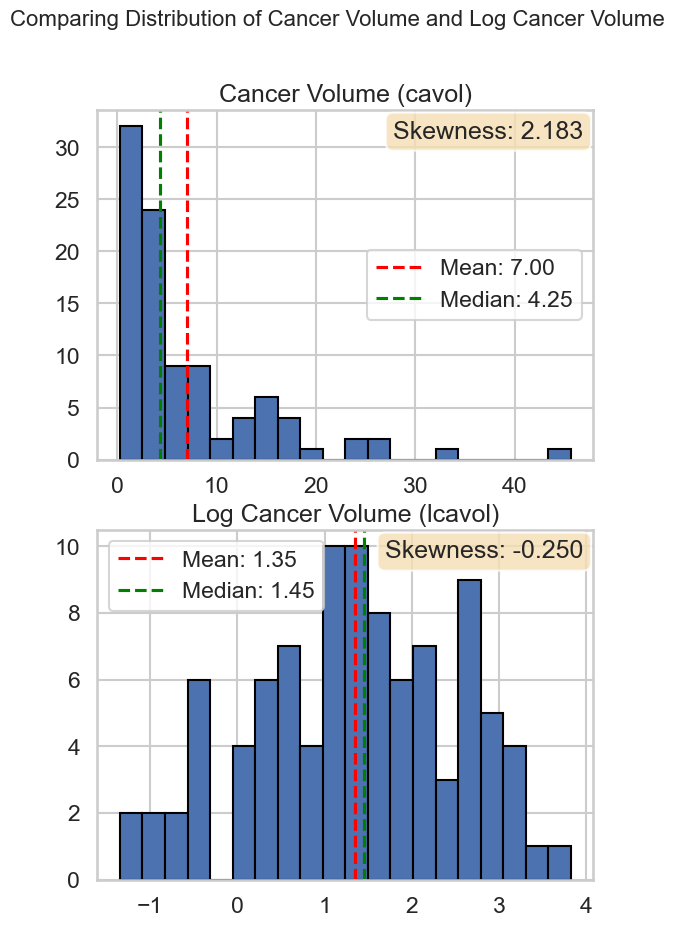

In [4]:
print('Values of svi: ', prostate_raw_csv['svi'].unique())
print('Values of gleason: ', prostate_raw_csv['gleason'].unique())
print('Values of pgg45: ', prostate_raw_csv['pgg45'].unique())

print('\n')
print('Looking a little closer at the lcavol data')
cavol = prostate_raw_csv['lcavol'].apply(lambda x: np.exp(x))
print(type(cavol))
display(cavol.describe())
print('median cancer volume', np.median(cavol))

fig, ax = plt.subplots(2)
fig.set_figheight(10)
lst = [cavol, prostate_raw_csv['lcavol']]
plt_titles = ['Cancer Volume (cavol)', 'Log Cancer Volume (lcavol)']
for i in range(2):
    ax[i].hist(lst[i], bins=20, edgecolor='black')
    ax[i].axvline(lst[i].mean(), color='red', linestyle='--', label=f'Mean: {lst[i].mean():.2f}')
    ax[i].text(0.98, 0.97, f'Skewness: {lst[i].skew():.3f}', transform=ax[i].transAxes, 
     verticalalignment='top', horizontalalignment='right', 
     bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    ax[i].axvline(lst[i].median(), color='green', linestyle='--', label=f'Median: {lst[i].median():.2f}')
    ax[i].set_title(plt_titles[i])
    ax[i].legend()
fig.suptitle('Comparing Distribution of Cancer Volume and Log Cancer Volume', fontsize=16)
    

In [5]:
weight = prostate_raw_csv['lweight'].apply(lambda x: np.exp(x))
display(weight.describe())
print('median weight:', weight.median())
print('skewness of weight:', weight.skew())
print('skewness of log weight:', prostate_raw_csv['lweight'].skew())

count     97.000000
mean      41.309278
std       19.090978
min       10.750003
25%       29.250012
50%       37.450011
75%       48.250008
max      119.149976
Name: lweight, dtype: float64

median weight: 37.45001086187867
skewness of weight: 1.6342867103181116
skewness of log weight: 0.06354142616877002


Next, we check for missing values (number of NaNs), and duplicates, and differentiate between categorical and numeric columns.

In [6]:
n_rows, n_cols = prostate_raw_csv.shape
n_duplicates = prostate_raw_csv.duplicated().sum()
n_nan = prostate_raw_csv.isna().sum().sum()

summary_table = pd.DataFrame({
    "n_rows": [n_rows],
    "n_columns": [n_cols],
    "n_duplicates": [n_duplicates],
    "n_nan": [n_nan],
    "duplicate_rate": [n_duplicates / n_rows]
})

display(summary_table)

,n_rows,n_columns,n_duplicates,n_nan,duplicate_rate
0,97,10,0,0,0.0


This dataset is exceptionally clean--it has no duplicates or missing values so we don't have to worry about dropping these later. Presumably this is why it was given to us as our first exercise in EDA.

In [7]:
numeric_cols = prostate_raw_csv.select_dtypes(include=np.number).columns.tolist()
categorical_cols = prostate_raw_csv.select_dtypes(exclude=np.number).columns.tolist()
continuous_columns = prostate_raw_csv.select_dtypes(include=['float']).columns.tolist()
discrete_columns = prostate_raw_csv.select_dtypes(include=['int']).columns.tolist()

print("Numeric columns:")
print(numeric_cols)
print("\nCategorical columns:")
print(categorical_cols)
print("\nContinuous columns:")
print(continuous_columns)
print("\nDiscrete columns:")
print(discrete_columns)

Numeric columns:
['lcavol', 'lweight', 'age', 'lbph', 'svi', 'lcp', 'gleason', 'pgg45', 'lpsa']

Categorical columns:
['train']

Continuous columns:
['lcavol', 'lweight', 'lbph', 'lcp', 'lpsa']

Discrete columns:
['age', 'svi', 'gleason', 'pgg45']


Next, we plot each variable individually to get a sense of the distribution.

/var/folders/cr/ypvbj1jj72b2bpf3mtz7x5100000gn/T/ipykernel_48635/3564248751.py:29: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


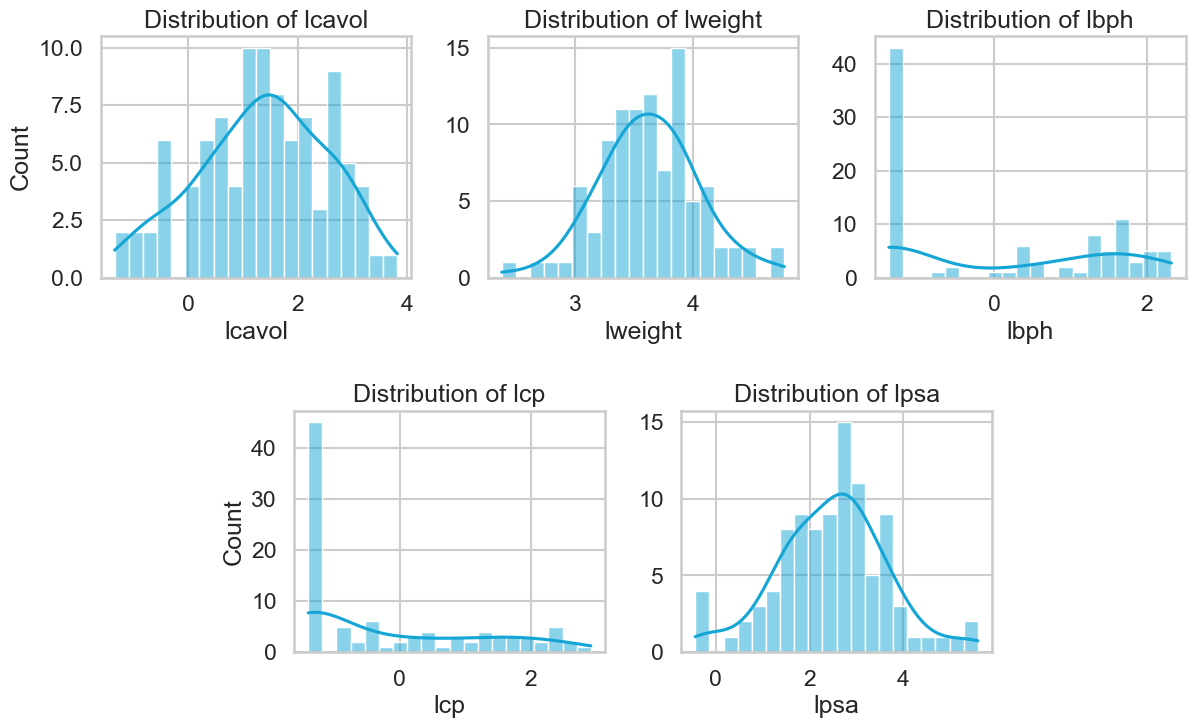

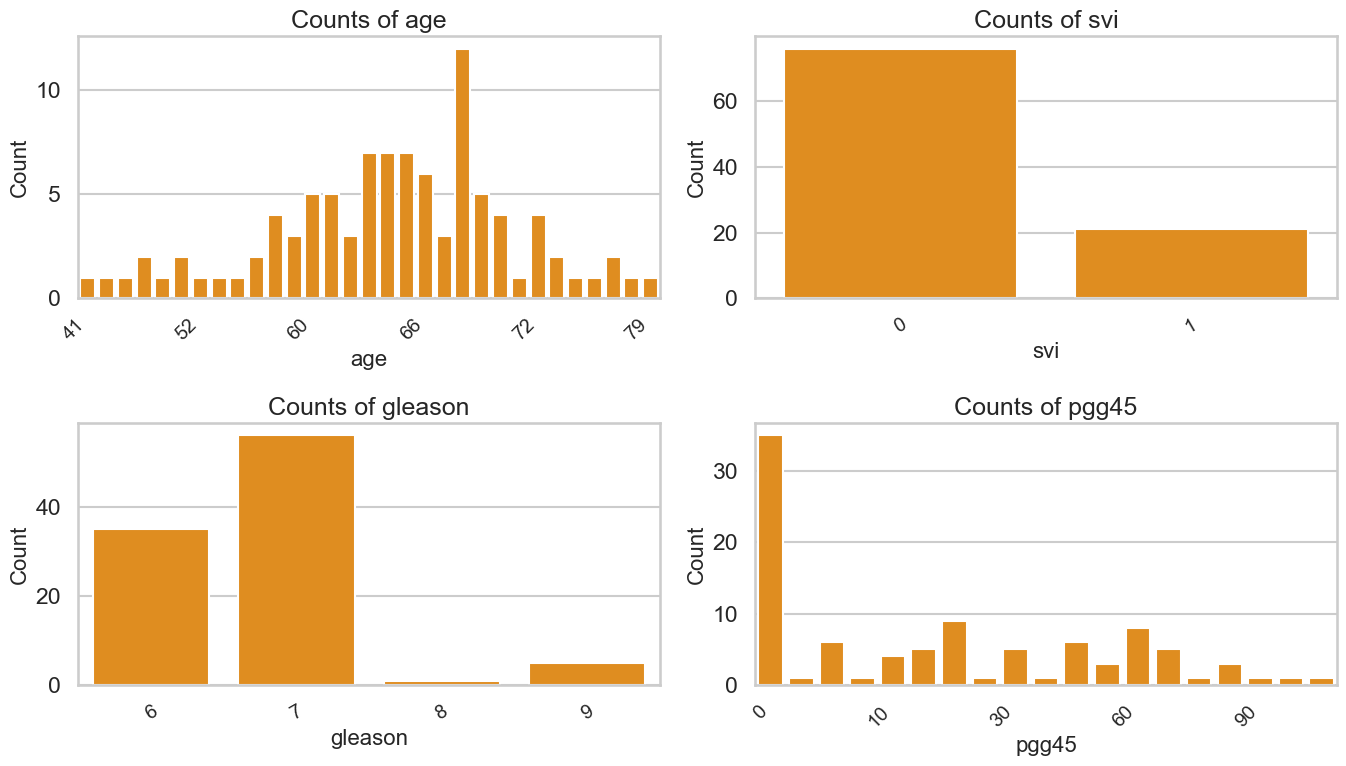

In [8]:

if "continuous_columns" not in globals() or "discrete_columns" not in globals():
    continuous_columns = prostate_raw_csv.select_dtypes(include=['float']).columns.tolist()
    discrete_columns = prostate_raw_csv.select_dtypes(include=['int']).columns.tolist()

# plot each continuous variable separately
cont_fig = plt.figure(figsize=(14, 8))
gs = gridspec.GridSpec(2, 6, figure=cont_fig, hspace=0.55, wspace=0.65)

# Top row: 3 plots
cont_ax1 = cont_fig.add_subplot(gs[0, 0:2])
cont_ax2 = cont_fig.add_subplot(gs[0, 2:4])
cont_ax3 = cont_fig.add_subplot(gs[0, 4:6])

# Bottom row: 2 plots, centered
cont_ax4 = cont_fig.add_subplot(gs[1, 1:3])
cont_ax5 = cont_fig.add_subplot(gs[1, 3:5])

continuous_axes = [cont_ax1, cont_ax2, cont_ax3, cont_ax4, cont_ax5]

for i, col in enumerate(continuous_columns):
    sns.histplot(prostate_raw_csv[col].dropna(), bins=20, kde=True, ax=continuous_axes[i], color="#15A6D6")
    continuous_axes[i].set_title(f"Distribution of {col}")
    continuous_axes[i].set_xlabel(col)
    if i in [0, 3]:  # Only leftmost columns of each row
        continuous_axes[i].set_ylabel("Count")
    else:
        continuous_axes[i].set_ylabel("")

plt.tight_layout()
plt.show()

# Discrete variables: use flattened axes and reference each axis as `ax`
disc_fig, disc_ax = plt.subplots(2, 2, figsize=(14, 8))
disc_axes = disc_ax.flatten()
# Plot each discrete variable separately.
for i, col in enumerate(discrete_columns):
    ax = disc_axes[i]
    # Sort order numerically (by value, not by frequency)
    order = sorted(prostate_raw_csv[col].unique())
    sns.countplot(data=prostate_raw_csv, x=col, order=order, ax=ax, color="#FF9100")
    ax.set_title(f"Counts of {col}")
    ax.set_xlabel(col, fontsize=16)
    ax.set_ylabel("Count", fontsize=16)
    # Reduce tick density for discrete variables with many unique values
    try:
        n_unique = len(order)
    except Exception:
        n_unique = prostate_raw_csv[col].nunique()
    if n_unique > 8:
        from matplotlib.ticker import MaxNLocator
        ax.xaxis.set_major_locator(MaxNLocator(nbins=6, integer=True))
        for lbl in ax.get_xticklabels():
            lbl.set_rotation(45)
            lbl.set_ha('right')
            lbl.set_fontsize(14)
    else:
        ax.tick_params(axis="x", rotation=30, labelsize=14)

plt.tight_layout()
plt.show()

### Notes from inspecting the histograms
##### Continuous
$\texttt{lcavol, lweight}$, and $\texttt{lpsa}$ are all approximately normally distributed. $\texttt{lbph}$ and $\texttt{lcp}$ both have a large peak to the left.In the case $\texttt{lcp}$, this comes from the fact that all small levels were set to 0.25 because of detection difficulties. For $\texttt{lbph}$, this may be an artifact of applying the logarithm. It is worth noting that all our continuous numeric data is logarithms, and thus does not actually correspond to real units.
##### Discrete
For the dicrete variables, age seems to be approximately normal. More $\texttt{svi}$ was absent than present, and more Gleason scores were 6 or 7 than 8 or 9. This indicates we are not looking as patients with the most fatal prostate cancer. The $\texttt{pgg45}$ followed the same pattern as $\texttt{lbph}$ and $\texttt{lcp}$: a lot of concentration towards lower values and otherwise fairly uniformally distributed.

## Outlier Detection: 3.5-SD Rule

Identify potential outliers in key predictor variables using a 3.5 standard deviation threshold. We visualize these outliers against the target variable (lpsa) to assess their impact.

,variable,mean,std,outlier_count,outlier_pct
0,lcavol,1.350,1.179,0,0.0
1,lweight,3.629,0.428,0,0.0
2,age,63.866,7.445,0,0.0
3,lbph,0.100,1.451,0,0.0
4,svi,0.216,0.414,0,0.0
5,lcp,-0.179,1.398,0,0.0
6,gleason,6.753,0.722,0,0.0
7,pgg45,24.381,28.204,0,0.0
8,train,0.691,0.465,0,0.0


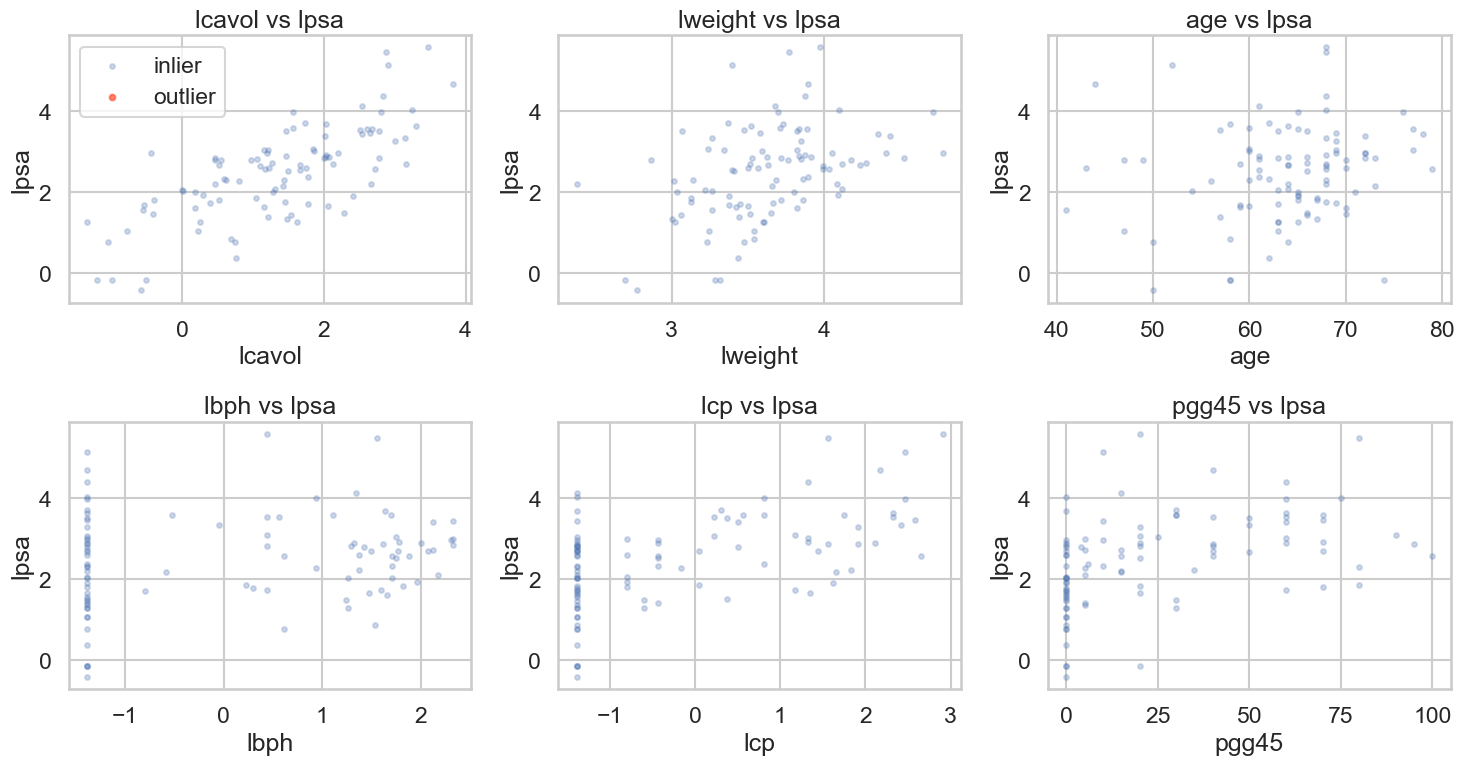

In [9]:
# Outlier detection using 3.5 SD rule on key continuous predictors
key_vars = [v for v in prostate_raw_csv.columns]
key_vars.remove('lpsa')
outlier_rows = []

for v in key_vars:
    mu = prostate_raw_csv[v].mean()
    sd = prostate_raw_csv[v].std()
    flag = (prostate_raw_csv[v] < mu - 3.5 * sd) | (prostate_raw_csv[v] > mu + 3.5 * sd)
    outlier_rows.append({
        "variable": v,
        "mean": mu,
        "std": sd,
        "outlier_count": int(flag.sum()),
        "outlier_pct": float(flag.mean() * 100),
    })

outlier_summary = pd.DataFrame(outlier_rows).sort_values("outlier_pct", ascending=False)
display(outlier_summary.round(3))

# Visualize outliers for continuous predictors only
continuous_key_vars = [v for v in key_vars if prostate_raw_csv[v].nunique() > 5]

if continuous_key_vars and "lpsa" in prostate_raw_csv.columns:
    fig, axes = plt.subplots(2, 3, figsize=(15, 8), squeeze=False)
    for i, v in enumerate(continuous_key_vars):
        row = i // 3
        col = i % 3
        mu = prostate_raw_csv[v].mean()
        sd = prostate_raw_csv[v].std()
        flag = (prostate_raw_csv[v] < mu - 3.5 * sd) | (prostate_raw_csv[v] > mu + 3.5 * sd)
        axes[row, col].scatter(prostate_raw_csv.loc[~flag, v], prostate_raw_csv.loc[~flag, "lpsa"], alpha=0.25, s=12, label="inlier")
        axes[row, col].scatter(prostate_raw_csv.loc[flag, v], prostate_raw_csv.loc[flag, "lpsa"], alpha=0.8, s=16, color="tomato", label="outlier")
        axes[row, col].set_title(f"{v} vs lpsa")
        axes[row, col].set_xlabel(v)
        axes[row, col].set_ylabel("lpsa")
    axes[0, 0].legend(loc="best")
    plt.tight_layout()
    plt.show()

There are no outliers! We now move on to exploring the dependency between explanatory variables with $\texttt{seaborn pairplot}$. We expect that prostate weight increases with increasing age as well as lbph (these are all positively correlated). We also predict that increased cancer volume is positively correlated with the other indicators of cancer severity, $\texttt{svi}$ and $\texttt{gleason}$.

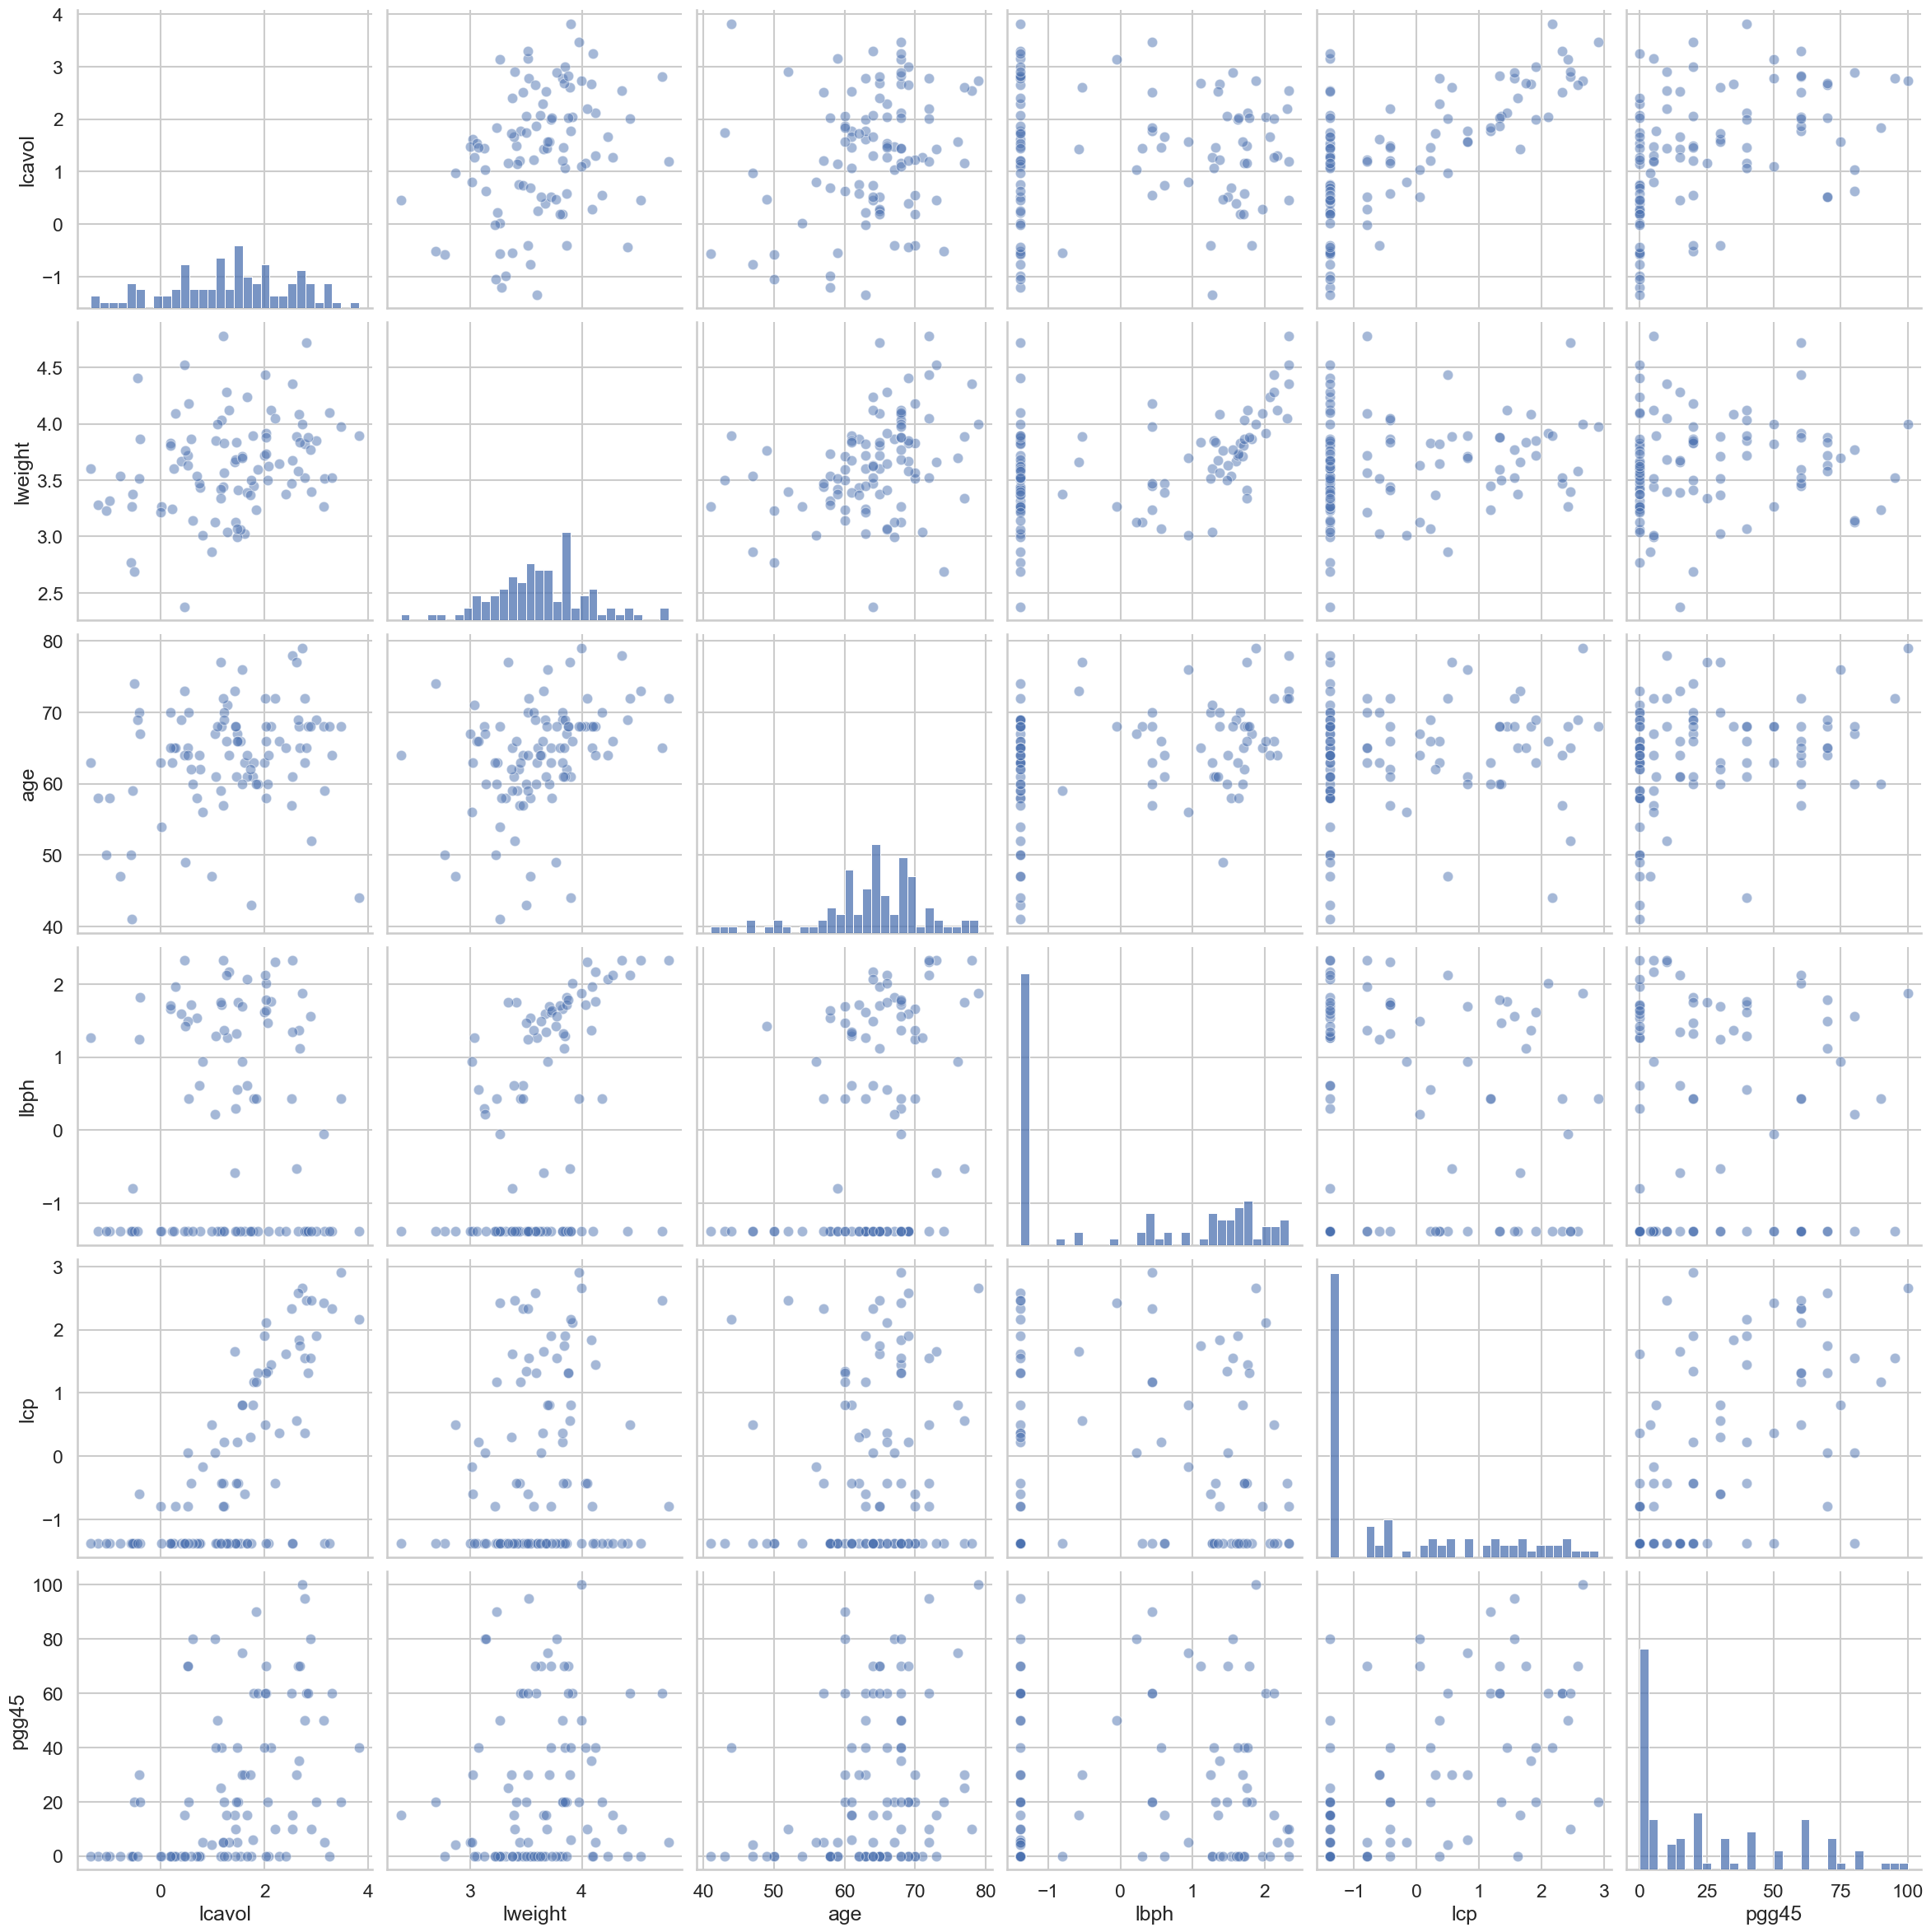

In [20]:

pairplot_columns = [col for col in prostate_raw_csv.columns if prostate_raw_csv[col].nunique() > 5 and col != 'lpsa']
temp_df = prostate_raw_csv[pairplot_columns].copy()
temp_df['age_group'] = pd.cut(prostate_raw_csv['age'], bins=6)

sns.pairplot(temp_df, height=4, diag_kind='hist', diag_kws={'bins': 30},
             plot_kws={'alpha': 0.5})
plt.show()


In the pariplot graph above, the diagonal graphs show the histograms of each explanatory variable on its own. The off-diagonal graphs show pairs of explanatory variables graphed against each other. The clearest correlations are found between:
- lcp and lcavol
- lbph and lweight
but running a regression and calculating the $R^2$ is neccasry to rigorously confirm.

We proceed to using bar-and-whisker plots to visualize the relationship between the explanatory variables that have a wider spectrum of values -- and those therefore closer to continuous, even if $\texttt{int}$'s, and those we treat as categorical variables.

In [ ]:
# Box and whisker plots: continuous vars vs gleason/svi
pairplot_columns = ['lcavol', 'lweight', 'age', 'lbph', 'lcp', 'pgg45']
cat_vars  = ['gleason', 'svi']

fig, axes = plt.subplots(len(pairplot_columns), len(cat_vars),
                         figsize=(5 * len(cat_vars), 4 * len(pairplot_columns)))

for i, cont in enumerate(pairplot_columns):
    for j, cat in enumerate(cat_vars):
        ax = axes[i, j]
        order = sorted(prostate_raw_csv[cat].unique())
        sns.boxplot(data=prostate_raw_csv, x=cat, y=cont, order=order, ax=ax)
        ax.set_title(f'{cont} by {cat}')
        ax.set_xlabel(cat)
        ax.set_ylabel(cont)

plt.tight_layout()
plt.show()

Sources
[1] Preoperative Determination of Prostate Cancer Tumor Volume:\
Analysis through Biopsy Fragments, Antunes
[2] https://pcri.org/news/2017/3/17/prostate-size-matters\
[3] https://pmc.ncbi.nlm.nih.gov/articles/PMC4548603/: "The Effect of Prostate Weigth on the Outcome of Robot-Assisted Radical Prostatectomy" Boylu et al, 2013\
[4] https://www.oncologyradiotherapy.com/articles/the-role-of-prostate-size-in-determining-serumic-psa-values-in-patients-with-benign-prostatic-hypertrophy.pdf "The Role of Prostate Size in Determining Serumic PSA Valies in Patients with Benign Prostatic Hypertrophy," Neziri et al, University Clinical Center of Kosovo\
[5] "Realtionship Between Age of Prostate Size," Zhang et al, 10.1038/aja.2012.127\
[6] "The relationship of preoperative PSA levels to prostatic weight and tumor size," Furusato et al, https://doi.org/10.1016/j.urology.2006.08.808\
[7] Baunacke et al, Increasing Age at Radical Prostatectomy: A Total Population Analysis in Germany from 2006 to 2022, https://doi.org/10.1245/s10434-025-18740-5\
[8] Isbarn et al, "Results of Radical Prostatectomy in Newly Diagnosed Prostate Cancer", 2013, https://doi.org/10.3238/arztebl.2013.0497\
[9] Mayo Clinic, "Benign Prostatic Hyperplasia"\
[10] "The Difference Between Prostate Cancre & BPH,"Dr Robert Grubb, MUSC Health, 2021, https://www.musc.edu/content-hub/News/2021/08/19/Prostate-Cancer-and-BPH.\
[11] Potter, "Seminal Vesicle Invasion by Prostate Cancer: Prognostic Significance and Therapeutic Implications", 2000, https://pubmed.ncbi.nlm.nih.gov/16985773/.\
[12], Behmeida et al, "Prognostic Factors in Prostate Cancer", 2005, https://doi.org/10.1186/1746-1596-1-4.\
[13] https://www.pcf.org/patient-support/diagnosis/gleason-score/.\
[14] "Gleason score grading for prostate cancer", Mayo Clinic Staff, https://www.mayoclinic.org/diseases-conditions/prostate-cancer/in-depth/gleason-score-grading-for-prostate-cancer/art-20593576\
[15] https://my.clevelandclinic.org/health/diagnostics/24615-psa-test.\
[16] Gretzer and Partin, "PSA Levels and the Probability of Prostate Cancer on Biopsy, 2002, https://www.eu-openscience.europeanurology.com/article/S1569-9056(02)00053-2/fulltext.